# Figures in This Notebook

- **Figure 4.** Geographic Distribution of Perinatal Conversational Agent Development
- **Figure 5.** Publications Over Time by Model Class
- **Figure 6.** Governance Maturity Profile across the six GSM Dimensions (Radar Chart)
 - **Figure 7.** Governance maturity by model class and crisis tier. - **Figure 8.** Clinical scope, function, and therauputic foundation. **Figure 7.** 

In [1]:
%pip install geopandas

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Using cached geopandas-1.1.4-py3-none-any.whl.metadata (2.3 kB)
Using cached geopandas-1.1.4-py3-none-any.whl (343 kB)
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   --- ------------------------------------ 2.1/23.8 MB 26.8 MB/s eta 0:00:01
   ---------------- ----------------------- 9.7/23.8 MB 23.4 MB/s eta 0:00:01
   ------------------------------ --------- 18.1/23.8 MB 28.2 MB/s eta 0:00:01
   ---------------------------------------  23.6/23.8 MB 29.6 MB/s eta 0:00:01
   ---------------------------------------- 23.8/23.8 MB 24.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 32.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 27

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


saved fig_geography.png / .pdf


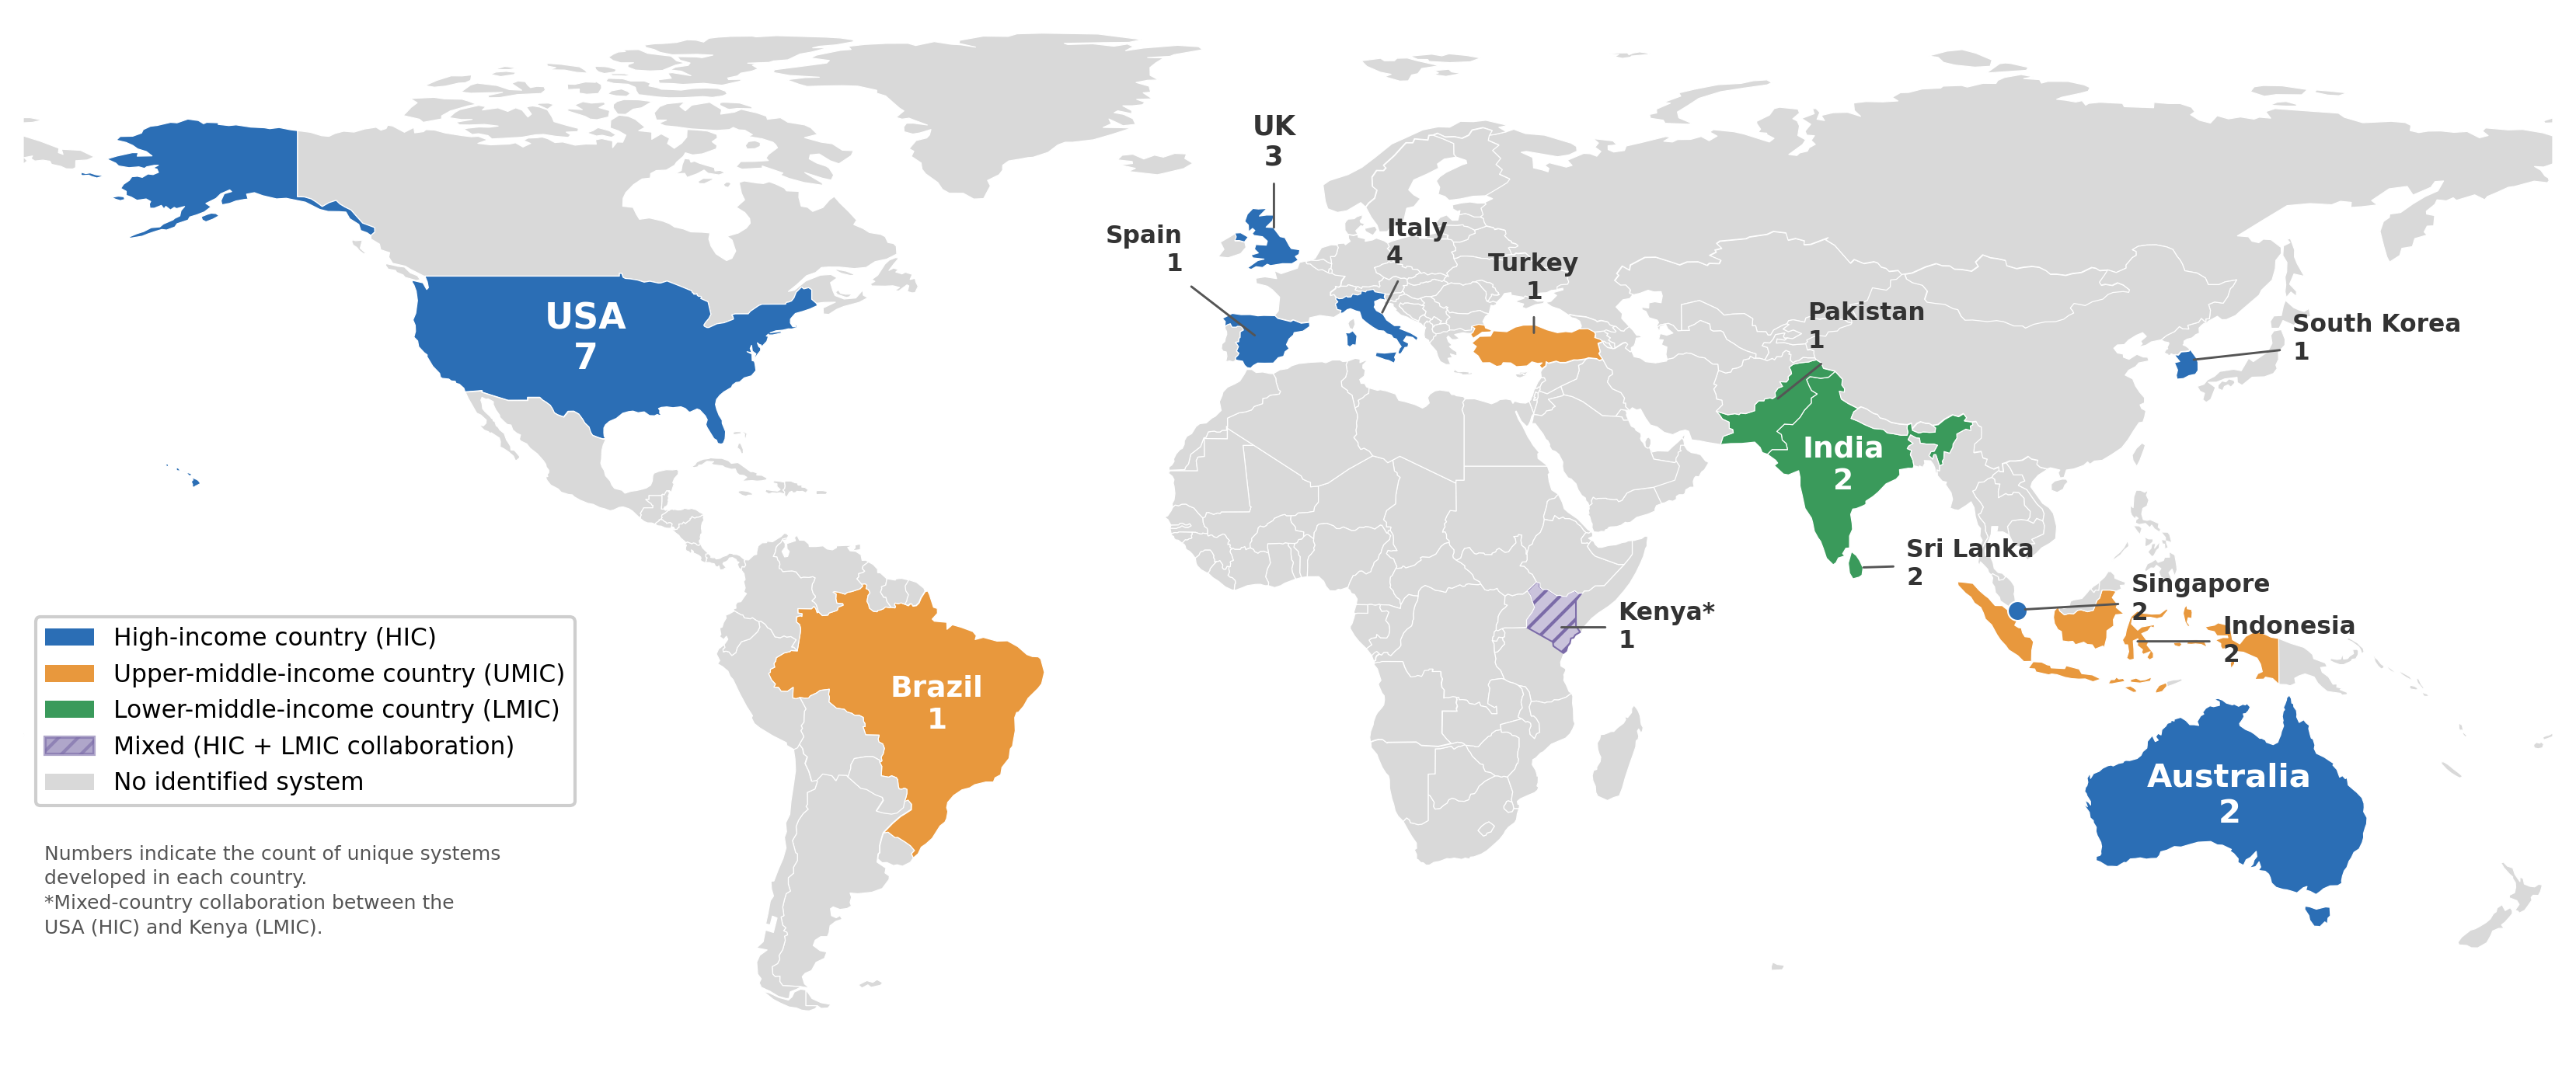

In [2]:
"""
Geographic distribution of perinatal mental health CA development
(unique systems, n = 30), coloured by World Bank income group.
"""
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import geopandas as gpd
import numpy as np

# ---- LOAD WORLD ----
world = gpd.read_file("countries.geojson")

# ---- DATA ----
country_data = {
    "United States of America": (7, "HIC"),
    "United Kingdom":           (3, "HIC"),
    "Italy":                    (4, "HIC"),
    "Spain":                    (1, "HIC"),
    "Australia":                (2, "HIC"),
    "South Korea":              (1, "HIC"),
    "Turkey":                   (1, "UMIC"),
    "Brazil":                   (1, "UMIC"),
    "Indonesia":                (2, "UMIC"),
    "India":                    (2, "LMIC"),
    "Sri Lanka":                (2, "LMIC"),
    "Pakistan":                 (1, "LMIC"),
    "Kenya":                    (1, "Mixed"),
}
# Singapore not in 110m shapefile — handle as point marker
singapore = (2, "HIC", 103.8, 1.35)

colors = {
    "HIC":   "#2B6EB5",
    "UMIC":  "#E8983D",
    "LMIC":  "#3A9A5B",
    "Mixed": "#7B6BA8",
    "none":  "#D9D9D9",
}

# Assign colors
world["color"] = colors["none"]
world["income"] = "none"
for _, row in world.iterrows():
    name = row["ADMIN"]
    if name in country_data:
        _, income = country_data[name]
        world.loc[world["ADMIN"] == name, "color"] = colors[income]
        world.loc[world["ADMIN"] == name, "income"] = income

# ---- FIGURE ----
fig, ax = plt.subplots(figsize=(14, 7.5), dpi=300, facecolor="white")
ax.set_facecolor("white")

# Draw all countries
for _, row in world.iterrows():
    income = row["income"]
    if income == "Mixed":
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color=colors["Mixed"], edgecolor="white",
                                           linewidth=0.3, alpha=0.4)
        gpd.GeoSeries([row.geometry]).plot(ax=ax, facecolor="none", edgecolor=colors["Mixed"],
                                           linewidth=0.5, hatch="////")
    else:
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color=row["color"], edgecolor="white", linewidth=0.3)

# Singapore as colored circle (too small for polygon at 110m)
ax.plot(singapore[2], singapore[3], "o", color=colors["HIC"], markersize=6,
        markeredgecolor="white", markeredgewidth=0.5, zorder=10)

# ---- LABELS ----
label_config = [
    # (lon_text, lat_text, text, fontsize, ha, va, arrow_to_lon, arrow_to_lat)
    # All small countries get sharp straight leader lines
    (-2,   64,   "UK\n3",            8.5, "center", "bottom", -2, 55),
    (-15,  49,   "Spain\n1",         7.5, "right", "bottom", -4, 40),
    (14,   50,   "Italy\n4",         7.5, "left", "bottom", 13, 43),
    (35,   45,   "Turkey\n1",        7.5, "center", "bottom", 35, 40),
    (143,  40,   "South Korea\n1",   7.5, "left", "center", 128, 37),
    (120,   3,   "Singapore\n2",     7.5, "left", "center", 104, 1.5),
    (133,  -3,   "Indonesia\n2",     7.5, "left", "center", 120, -3),
    (88,    8,   "Sri Lanka\n2",     7.5, "left", "center", 81, 7.5),
    (74,   38,   "Pakistan\n1",      7.5, "left", "bottom", 69, 31),
    (47,   -1,   "Kenya*\n1",        7.5, "left", "center", 38, -1),
]

for item in label_config:
    tx, ty, text, fs, ha, va, ax2, ay2 = item
    if ax2 is not None:
        # Leader line
        ax.annotate(text, xy=(ax2, ay2), xytext=(tx, ty),
                    fontsize=fs, fontweight="bold", color="#333333",
                    ha=ha, va=va,
                    arrowprops=dict(arrowstyle="-", color="#555555", lw=0.7,
                                   connectionstyle="arc3,rad=0.0"),
                    zorder=15)
    else:
        ax.text(tx, ty, text, fontsize=fs, fontweight="bold", color="#333333",
                ha=ha, va=va, zorder=15)

# White text for large colored countries
for tx, ty, text, fs in [(-100, 40, "USA\n7", 11), (134, -25, "Australia\n2", 10),
                          (-50, -12, "Brazil\n1", 9), (79, 22, "India\n2", 9)]:
    ax.text(tx, ty, text, fontsize=fs, fontweight="bold", color="white",
            ha="center", va="center", zorder=16)

# Remove the black-text duplicates for these countries by drawing white over

# ---- AXES ----
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_aspect("equal")
ax.axis("off")


# ---- LEGEND ----
legend_items = [
    mpatches.Patch(facecolor=colors["HIC"], edgecolor="none", label="High-income country (HIC)"),
    mpatches.Patch(facecolor=colors["UMIC"], edgecolor="none", label="Upper-middle-income country (UMIC)"),
    mpatches.Patch(facecolor=colors["LMIC"], edgecolor="none", label="Lower-middle-income country (LMIC)"),
    mpatches.Patch(facecolor=colors["Mixed"], edgecolor=colors["Mixed"],
                   label="Mixed (HIC + LMIC collaboration)", hatch="////", alpha=0.6),
    mpatches.Patch(facecolor=colors["none"], edgecolor="none", label="No identified system"),
]
leg = ax.legend(handles=legend_items, loc="lower left", fontsize=7.5,
                frameon=True, framealpha=0.95, edgecolor="#CCCCCC",
                bbox_to_anchor=(0.0, 0.22))

# Footnotes
# Footnotes aligned directly under legend
ax.text(-177, -32,
        "Numbers indicate the count of unique systems\ndeveloped in each country.",
        fontsize=6, color="#555555", va="top", linespacing=1.4)
ax.text(-177, -39,
        "*Mixed-country collaboration between the\nUSA (HIC) and Kenya (LMIC).",
        fontsize=6, color="#555555", va="top", linespacing=1.4)


plt.savefig("fig_geography.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.savefig("fig_geography.pdf", bbox_inches="tight", facecolor="white")
print("saved fig_geography.png / .pdf")

saved fig_pubtime.png / .pdf


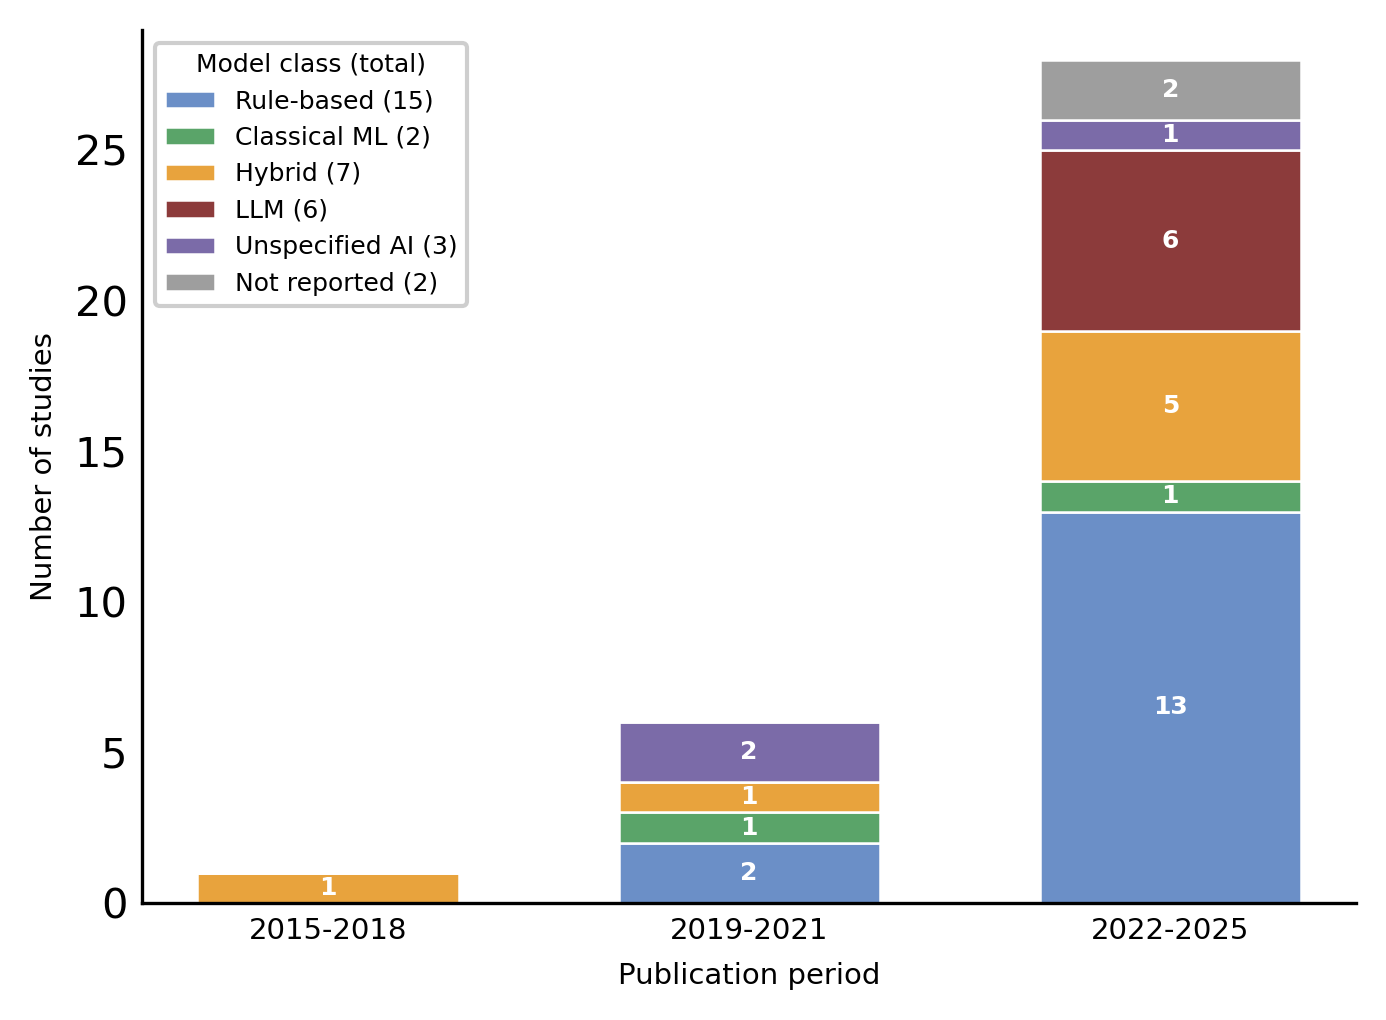

In [5]:
"""
Publications over time by model class (N = 34 studies)
Stacked bar chart with non-overlapping publication periods.
"""
import matplotlib.pyplot as plt
import numpy as np

# ---- DATA: study ID -> (model class, year bin) ----
# Year bins: a=2015-2018, b=2019-2021, c=2022-2025
studies = {
    33: ("Hybrid", "a"),
    2:  ("Unspecified AI", "b"),
    3:  ("Unspecified AI", "b"),
    9:  ("Classical ML", "b"),
    18: ("Hybrid", "b"),
    23: ("Rule-based", "b"),
    32: ("Rule-based", "b"),
    1:  ("Rule-based", "c"),
    4:  ("Hybrid", "c"),
    5:  ("Rule-based", "c"),
    6:  ("LLM", "c"),
    7:  ("LLM", "c"),
    8:  ("Rule-based", "c"),
    10: ("Classical ML", "c"),
    11: ("LLM", "c"),
    12: ("LLM", "c"),
    13: ("Hybrid", "c"),
    14: ("Rule-based", "c"),
    15: ("Hybrid", "c"),
    16: ("Rule-based", "c"),
    17: ("Rule-based", "c"),
    19: ("Hybrid", "c"),
    20: ("LLM", "c"),
    21: ("Not reported", "c"),
    22: ("Rule-based", "c"),
    24: ("LLM", "c"),
    25: ("Not reported", "c"),
    26: ("Rule-based", "c"),
    27: ("Rule-based", "c"),
    28: ("Rule-based", "c"),
    29: ("Hybrid", "c"),
    30: ("Rule-based", "c"),
    31: ("Unspecified AI", "c"),
    34: ("Rule-based", "c"),
    35: ("Rule-based", "c")
}

# ---- CONFIGURATION ----
periods = ["a", "b", "c"]
period_labels = ["2015-2018", "2019-2021", "2022-2025"]
classes = ["Rule-based", "Classical ML", "Hybrid", "LLM", "Unspecified AI", "Not reported"]
colors = {
    "Rule-based":      "#6B8FC7",
    "Classical ML":    "#5AA469",
    "Hybrid":          "#E8A33D",
    "LLM":             "#8C3B3B",
    "Unspecified AI":  "#7B6BA8",
    "Not reported":    "#9E9E9E",
}

# ---- COUNT MATRIX ----
counts = {c: [0, 0, 0] for c in classes}
for sid, (cls, period) in studies.items():
    counts[cls][periods.index(period)] += 1

# Verify totals
totals = {c: sum(counts[c]) for c in classes}
assert sum(totals.values()) == 35, f"Total studies = {sum(totals.values())}, expected 35"

# ---- FIGURE ----
fig, ax = plt.subplots(figsize=(4.72, 3.5), dpi=300)

x = np.arange(3)
bar_width = 0.62
bottom = np.zeros(3)

for cls in classes:
    vals = np.array(counts[cls])
    ax.bar(
        x, vals, bottom=bottom, width=bar_width,
        color=colors[cls],
        label=f"{cls} ({totals[cls]})",
        edgecolor="white", linewidth=0.6,
    )
    # Value labels inside each segment
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax.text(
                xi, b + v / 2, str(int(v)),
                ha="center", va="center",
                fontsize=6, color="white", fontweight="bold",
            )
    bottom += vals

# Axes
ax.set_xticks(x)
ax.set_xticklabels(period_labels, fontsize=7)
ax.set_ylabel("Number of studies", fontsize=7)
ax.set_xlabel("Publication period", fontsize=7)
ax.set_ylim(0, 29)
ax.set_yticks(range(0, 30, 5))

# Title
#ax.set_title(
#    "Publications over time by model class (N = 35 studies)",
#    fontsize=6, fontweight="bold", pad=12,
#)

# Spines
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)

# Legend
ax.legend(
    fontsize=6, loc="upper left",
    frameon=True, framealpha=0.95,
    title="Model class (total)", title_fontsize=6,
)

plt.tight_layout()
plt.savefig("fig_pubtime.png", bbox_inches="tight", dpi=300)
plt.savefig("fig_pubtime.pdf", bbox_inches="tight")
print("saved fig_pubtime.png / .pdf")

Dimension means: {'Privacy': np.float64(0.89), 'Safety': np.float64(1.57), 'Monitoring': np.float64(0.46), 'Regulation': np.float64(1.23), 'Bias & fairness': np.float64(2.0), 'Consent': np.float64(1.34)}
saved fig_radar_corrected.png / .pdf


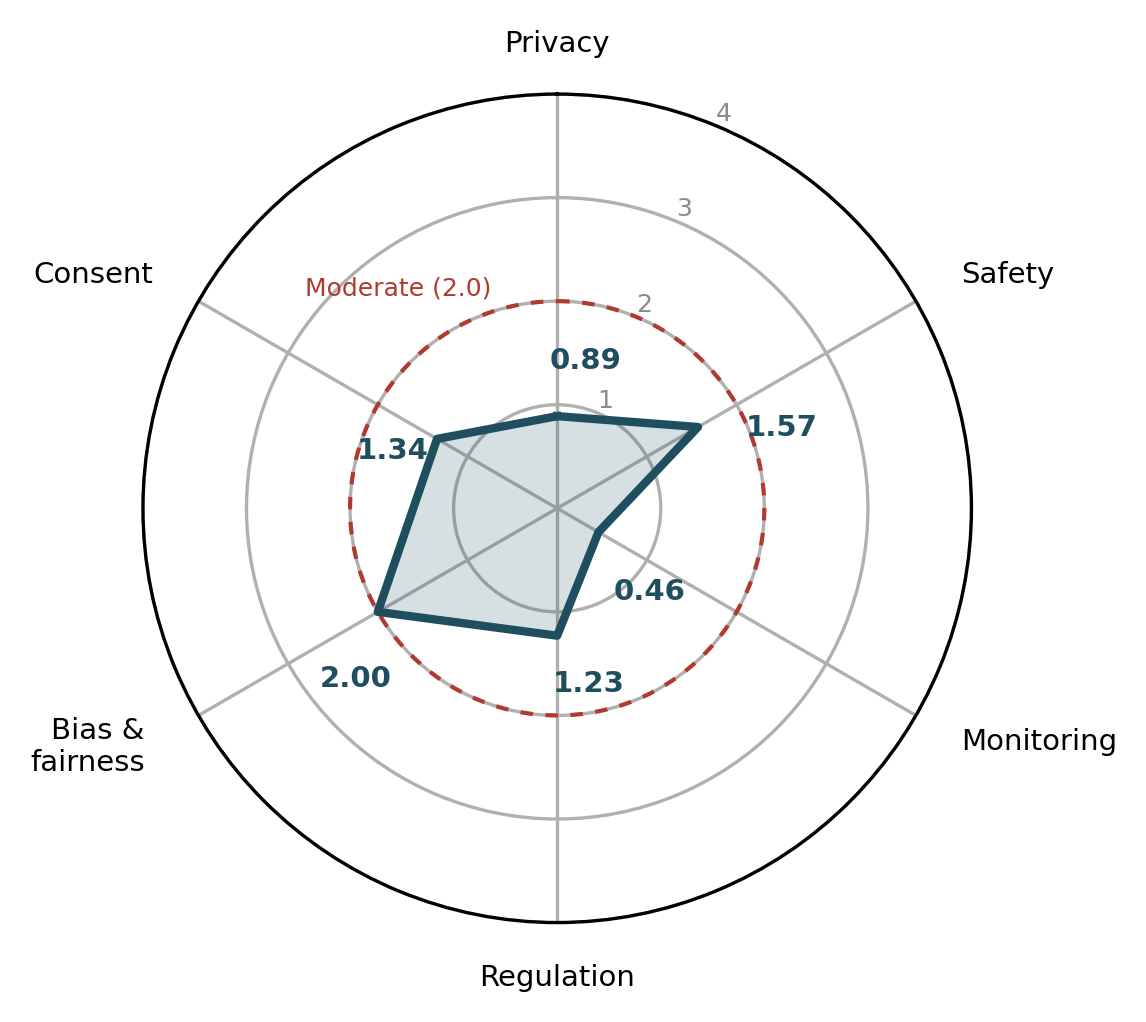

In [ ]:
"""
Governance Maturity Profile (Radar Chart)
Mean score per GMS dimension (0-4), across all 34 studies.
"""
import matplotlib.pyplot as plt
import numpy as np

# ---- DATA: verified per-study dimension scores ----
# (privacy, safety, monitoring, regulation, bias, consent)
dims = {
    1:  (2,2,0,2,2,3),  2:  (2,3,2,2,3,2),  3:  (0,1,0,0,1,0),  4:  (1,1,0,0,2,0),
    5:  (0,3,1,2,3,2),  6:  (0,2,1,0,1,0),  7:  (1,1,1,3,2,2),  8:  (0,3,0,1,2,2),
    9:  (0,2,0,0,2,0),  10: (0,2,0,0,2,0),  11: (0,1,0,1,3,2),  12: (0,0,0,1,3,3),
    13: (0,2,0,0,1,0),  14: (2,2,1,2,2,2),  15: (0,3,0,0,0,0),  16: (2,1,0,3,2,3),
    17: (2,3,1,2,2,2),  18: (0,2,0,1,2,0),  19: (0,1,1,2,1,2),  20: (0,0,0,0,2,1),
    21: (1,1,0,0,3,0),  22: (2,2,1,3,2,4),  23: (0,0,1,2,3,2),  24: (2,0,1,0,3,0),
    25: (0,0,0,3,1,2),  26: (2,1,1,3,2,4),  27: (1,2,0,1,3,2),  28: (2,0,1,1,3,1),
    29: (2,3,2,2,2,3),  30: (1,3,0,4,2,0),  31: (2,0,1,0,2,1),  32: (3,2,0,0,0,0),
    33: (1,2,0,0,0,2),  34: (0,2,0,0,3,0),  35: (0,2,0,2,3,0),
}
# tuple order: (privacy, safety, monitoring, regulation, bias, consent)

labels = ["Privacy", "Safety", "Monitoring", "Regulation", "Bias &\nfairness", "Consent"]
means = [round(np.mean([dims[s][d] for s in dims]), 2) for d in range(6)]
print("Dimension means:", dict(zip([l.replace('\n',' ') for l in labels], means)))
assert sum(sum(v) for v in dims.values()) == 262, "grid total mismatch"

N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
vals = means + means[:1]
angles2 = angles + angles[:1]

fig, ax = plt.subplots(figsize=(3.9, 3.9), subplot_kw=dict(polar=True), dpi=300)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_ylim(0, 4)

# radial gridlines/labels UNDER the data; keep the "1" ring tick away from the top vertex
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1", "2", "3", "4"], fontsize=6, color="#8a8a8a")
ax.tick_params(axis='y', pad=0)
ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_axisbelow(True)

# dimension name labels (outside the outer ring)
label_positions = [
    (angles[0], 4.35, "Privacy",          "center", "bottom"),
    (angles[1], 4.5,  "Safety",           "left",   "center"),
    (angles[2], 4.5,  "Monitoring",       "left",   "center"),
    (angles[3], 4.4,  "Regulation",       "center", "top"),
    (angles[4], 4.6,  "Bias &\nfairness", "right",  "center"),
    (angles[5], 4.5,  "Consent",          "right",  "center"),
]
for angle, r, lbl, ha, va in label_positions:
    ax.text(angle, r, lbl, ha=ha, va=va, fontsize=7, fontweight="medium")

# Moderate threshold ring FIRST (so value labels sit on top of it)
theta_ring = np.linspace(0, 2 * np.pi, 200)
ax.plot(theta_ring, [2.0] * 200, linestyle=(0, (3, 3)), color="#B03A2E", linewidth=1, zorder=3)
ax.text(np.deg2rad(324), 2.62, "Moderate (2.0)", color="#B03A2E", fontsize=6, ha="center", va="center", zorder=4)

# profile polygon
ax.plot(angles2, vals, color="#1F4E5F", linewidth=2, zorder=5)
ax.fill(angles2, vals, color="#1F4E5F", alpha=0.18, zorder=2)

# value labels: nudged into the empty wedge BETWEEN spokes (angular offset) and set
# just outside each vertex, so no label overlaps a spoke, ring, or the profile line.
# No halo is used, so every gridline stays fully continuous.
half = np.pi / N                      # half the angular gap between adjacent spokes
# Each label: angular shift into the empty wedge (off the spokes) + a hand-tuned
# radius that avoids the 1/2/3 ring circles. No halo, so gridlines stay continuous.
place = [  # (angular shift, radius)
    ( +0.36*half, 1.45),   # Privacy    (0.91) -> between rings 1 and 2
    ( +0.34*half, 2.30),   # Safety     (1.56) -> outside ring 2
    ( +0.40*half, 1.20),   # Monitoring (0.47) -> between rings 1 and 2, off the spoke
    ( -0.34*half, 1.72),   # Regulation (1.21) -> between rings 1 and 2
    ( -0.34*half, 2.55),   # Bias&fair  (1.97) -> outside ring 2
    ( -0.36*half, 1.68),   # Consent    (1.38) -> between rings 1 and 2
]
for a, v, (sh, r) in zip(angles, means, place):
    ax.text(a + sh, r, f"{v:.2f}", ha="center", va="center",
            fontsize=7, color="#1F4E5F", fontweight="bold", zorder=6)

#ax.set_title("Governance Maturity Profile (mean score per dimension, 0-4)",
#             fontsize=6.5, pad=20, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_radar_corrected.png", bbox_inches="tight", dpi=300)
plt.savefig("fig_radar_corrected.pdf", bbox_inches="tight") 

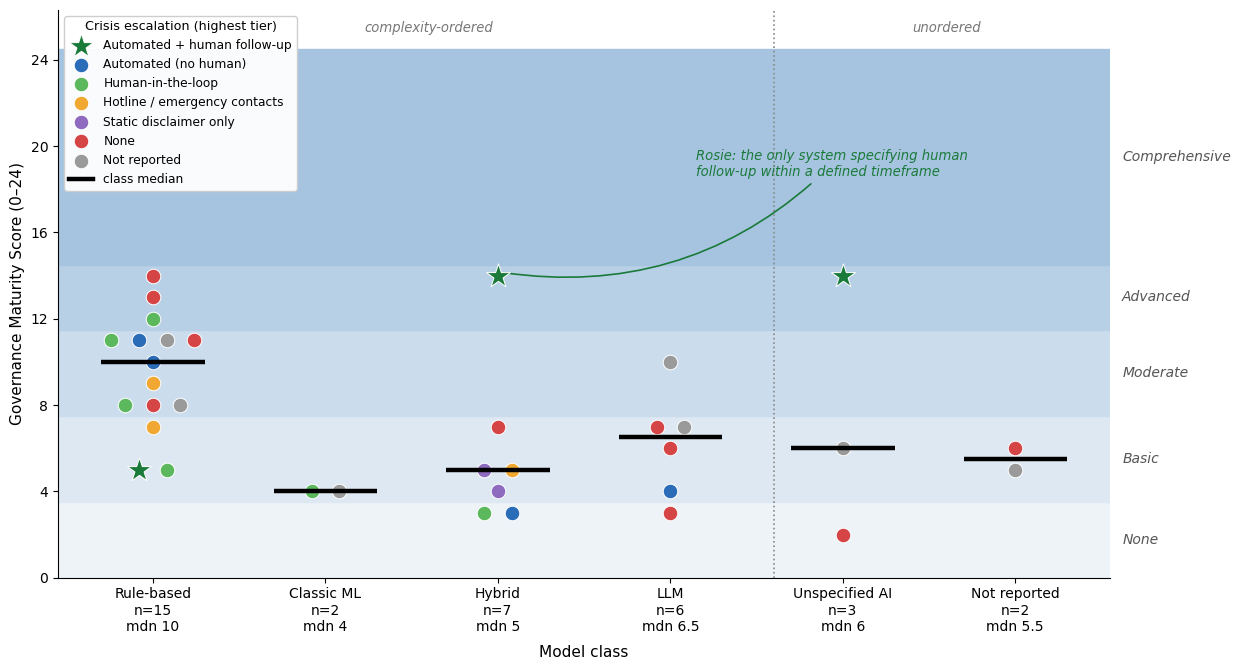

In [12]:

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from collections import Counter

data = {
 "Rule-based":[(1,11,"HIL"),(5,11,"AUTO"),(8,8,"HIL"),(14,11,"NR"),(16,11,"NONE"),
               (17,12,"HIL"),(22,14,"NONE"),(23,8,"NONE"),(26,13,"NONE"),(27,9,"HOT"),
               (28,8,"NR"),(30,10,"AUTO"),(32,5,"AH"),(34,5,"HIL"), (35,7,"HOT")],
 "Classic ML":[(9,4,"HIL"),(10,4,"NR")],
 "Hybrid":[(4,4,"DISC"),(13,3,"HIL"),(15,3,"AUTO"),(18,5,"DISC"),(19,7,"NONE"),
           (29,14,"AH"),(33,5,"HOT")],
 "LLM":[(6,4,"AUTO"),(7,10,"NR"),(11,7,"NONE"),(12,7,"NR"),(20,3,"NONE"),(24,6,"NONE")],
 "Unspecified AI":[(2,14,"AH"),(3,2,"NONE"),(31,6,"NR")],
 "Not reported":[(21,5,"NR"),(25,6,"NONE")],
}

tier_style = {
 "AH":  dict(c="#1a7a3a", marker="*", s=330, label="Automated + human follow-up", z=6),
 "AUTO":dict(c="#2b6cb8", marker="o", s=110, label="Automated (no human)",        z=5),
 "HIL": dict(c="#5cb85c", marker="o", s=110, label="Human-in-the-loop",           z=5),
 "HOT": dict(c="#f0a832", marker="o", s=110, label="Hotline / emergency contacts",z=5),
 "DISC":dict(c="#8e6bbf", marker="o", s=110, label="Static disclaimer only",      z=5),
 "NONE":dict(c="#d64545", marker="o", s=110, label="None",                        z=5),
 "NR":  dict(c="#9a9a9a", marker="o", s=110, label="Not reported",                z=5),
}

fig, ax = plt.subplots(figsize=(12.5, 6.8))
bands  = [(0,3.5,"None"),(3.5,7.5,"Basic"),(7.5,11.5,"Moderate"),
          (11.5,14.5,"Advanced"),(14.5,24.5,"Comprehensive")]
shades = ["#eef3f8","#dde8f2","#cbdcec","#b8d0e6","#a6c4e0"]
for (lo,hi,lab),sh in zip(bands,shades):
    ax.axhspan(lo,hi,color=sh,zorder=0)
    ax.text(5.62,(lo+min(hi,24.5))/2,lab,fontsize=10,style="italic",color="#555",va="center")
    
classes=list(data.keys()); seen=set()
for xi,cl in enumerate(classes):
    pts=data[cl]; ys=[p[1] for p in pts]
    cnt=Counter(ys); off={}
    xs=[]
    for s,y,t in pts:
        k=cnt[y]; i=off.get(y,0); off[y]=i+1
        xs.append(xi+(0 if k==1 else (i-(k-1)/2)*0.16))
    for (s,y,t),x in zip(pts,xs):
        st=tier_style[t]
        lab=st["label"] if st["label"] not in seen else None
        seen.add(st["label"])
        ax.scatter(x,y,c=st["c"],marker=st["marker"],s=st["s"],label=lab,
                   zorder=st["z"],edgecolors="white",linewidths=0.7)
    ax.hlines(np.median(ys),xi-0.3,xi+0.3,color="black",lw=3.2,zorder=7)
ax.axvline(3.6,color="#888",ls=":",lw=1.2)
ax.text(1.6,25.3,"complexity-ordered",fontsize=9.5,color="#777",style="italic",ha="center")
ax.text(4.6,25.3,"unordered",fontsize=9.5,color="#777",style="italic",ha="center")
meds={cl:np.median([p[1] for p in data[cl]]) for cl in classes}
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([f"{cl}\nn={len(data[cl])}\nmdn {meds[cl]:g}" for cl in classes],fontsize=10)
ax.set_ylim(0,26.3); ax.set_yticks(range(0,25,4)); ax.set_xlim(-0.55,5.55)
ax.set_ylabel("Governance Maturity Score (0\u201324)",fontsize=11)
ax.set_xlabel("Model class",fontsize=11,labelpad=8)
ax.annotate("Rosie: the only system specifying human\nfollow-up within a defined timeframe",
            xy=(2.02,14.15),xytext=(3.15,18.6),fontsize=9.5,color="#1a7a3a",style="italic",
            arrowprops=dict(arrowstyle="-",color="#1a7a3a",lw=1.2,
                            connectionstyle="arc3,rad=-0.25"))

order=["Automated + human follow-up","Automated (no human)","Human-in-the-loop",
       "Hotline / emergency contacts","Static disclaimer only","None","Not reported"]
handles,labs=ax.get_legend_handles_labels(); hl=dict(zip(labs,handles))
med_h=mlines.Line2D([],[],color="black",lw=3.2,label="class median")
ax.legend([hl[o] for o in order]+[med_h],order+["class median"],loc="upper left",
          fontsize=8.8,title="Crisis escalation (highest tier)",title_fontsize=9.2,framealpha=0.95)

for sp in ["top","right"]: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig("Fig5_safety_autonomy.png",dpi=300,bbox_inches="tight")
plt.show()


saved fig6a_governance_by_model_class.png / .pdf


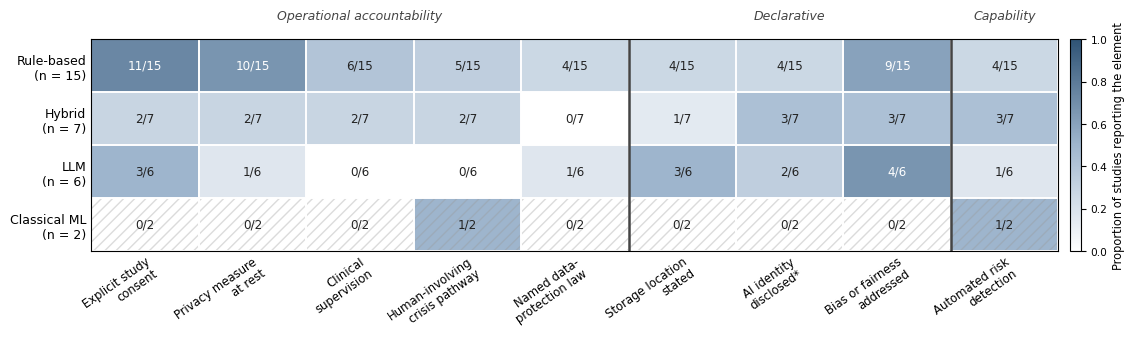

In [ ]:
"""
Fig. 6a | Governance elements reported by model class.

"""
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --------------------------------------------------------------------- data
_D = next((p for p in ("data", os.path.join("..", "data"))
           if os.path.isdir(p)), None)

# element key -> (display label, block)
ELEMENTS = [
    ("explicit_consent",     "Explicit study\nconsent",          "Operational accountability"),
    ("privacy_at_rest",      "Privacy measure\nat rest",         "Operational accountability"),
    ("clinical_supervision", "Clinical\nsupervision",            "Operational accountability"),
    ("human_crisis_pathway", "Human-involving\ncrisis pathway",  "Operational accountability"),
    ("named_regulation",     "Named data-\nprotection law",      "Operational accountability"),
    ("storage_location",     "Storage location\nstated",         "Declarative"),
    ("ai_identity",          "AI identity\ndisclosed*",          "Declarative"),
    ("bias_fairness",        "Bias or fairness\naddressed",      "Declarative"),
    ("automated_detection",  "Automated risk\ndetection",        "Capability"),
]
CLASSES = ["Rule-based", "Hybrid", "LLM", "Classical ML"]

if _D:
    cls = {int(r["study_id"]): r["model_class_analytic"].strip()
           for r in csv.DictReader(open(os.path.join(_D, "gms_scores.csv")))}
    rows = list(csv.DictReader(open(os.path.join(_D, "governance_elements.csv"))))
    denominators = np.array([sum(1 for r in rows if cls[int(r["study_id"])] == c)
                             for c in CLASSES])
    counts = np.array([[sum(1 for r in rows
                            if cls[int(r["study_id"])] == c and r[k] == "1")
                        for k, _, _ in ELEMENTS] for c in CLASSES])
else:                                   # fallback: values as charted
    denominators = np.array([15, 7, 6, 2])
    counts = np.array([                 # order matches ELEMENTS above
        [11, 10, 6, 5, 4, 4, 4, 9, 4],  # Rule-based
        [2,   2, 2, 2, 0, 1, 3, 3, 3],  # Hybrid
        [3,   1, 0, 0, 1, 3, 2, 4, 1],  # LLM
        [0,   0, 0, 1, 0, 0, 0, 0, 1],  # Classical ML
    ])

proportions = counts / denominators[:, None]
labels = [lab for _, lab, _ in ELEMENTS]
blocks = [b for _, _, b in ELEMENTS]

# ------------------------------------------------------------------ heatmap
# Sequential single hue: white = not reported, dark = reported.
# Viridis is avoided because its zero end is dark and reads as "high".
cmap = LinearSegmentedColormap.from_list("gov", ["#FFFFFF", "#9FB6CE", "#2F5375"])

fig, ax = plt.subplots(figsize=(11.5, 3.6))
im = ax.imshow(proportions, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right",
                   rotation_mode="anchor", fontsize=8.4)
ax.set_yticks(np.arange(len(CLASSES)))
ax.set_yticklabels([f"{c}\n(n = {n})" for c, n in zip(CLASSES, denominators)],
                   fontsize=9)

# cell labels: contrast follows the cell value, not a fixed colour
for i in range(len(CLASSES)):
    for j in range(len(labels)):
        ax.text(j, i, f"{counts[i, j]}/{denominators[i]}",
                ha="center", va="center", fontsize=8.6,
                color="white" if proportions[i, j] > 0.5 else "#222222")

# block dividers and headings
x = -0.5
for name in ("Operational accountability", "Declarative", "Capability"):
    w = blocks.count(name)
    if x > -0.5:
        ax.axvline(x, color="#444444", lw=1.8)
    ax.text(x + w / 2, -0.82, name, ha="center", va="bottom",
            fontsize=9, style="italic", color="#444444")
    x += w

# white gridlines
ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(CLASSES), 1), minor=True)
ax.grid(which="minor", color="white", lw=1.4)
ax.tick_params(which="minor", length=0)
ax.tick_params(axis="both", which="major", length=0)

# flag the underpowered row: n = 2 makes proportions uninformative
ax.add_patch(plt.Rectangle((-0.5, len(CLASSES) - 1.5), len(labels), 1,
                           fill=False, hatch="///", edgecolor="#999999",
                           lw=0, alpha=0.35))

cbar = fig.colorbar(im, ax=ax, fraction=0.016, pad=0.012)
cbar.set_label("Proportion of studies reporting the element", fontsize=8.2)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.ax.tick_params(labelsize=7.6)

plt.tight_layout()
plt.savefig("fig6a_governance_by_model_class.png", dpi=600,
            bbox_inches="tight", facecolor="white")
plt.savefig("fig6a_governance_by_model_class.pdf",
            bbox_inches="tight", facecolor="white") 
plt.show()

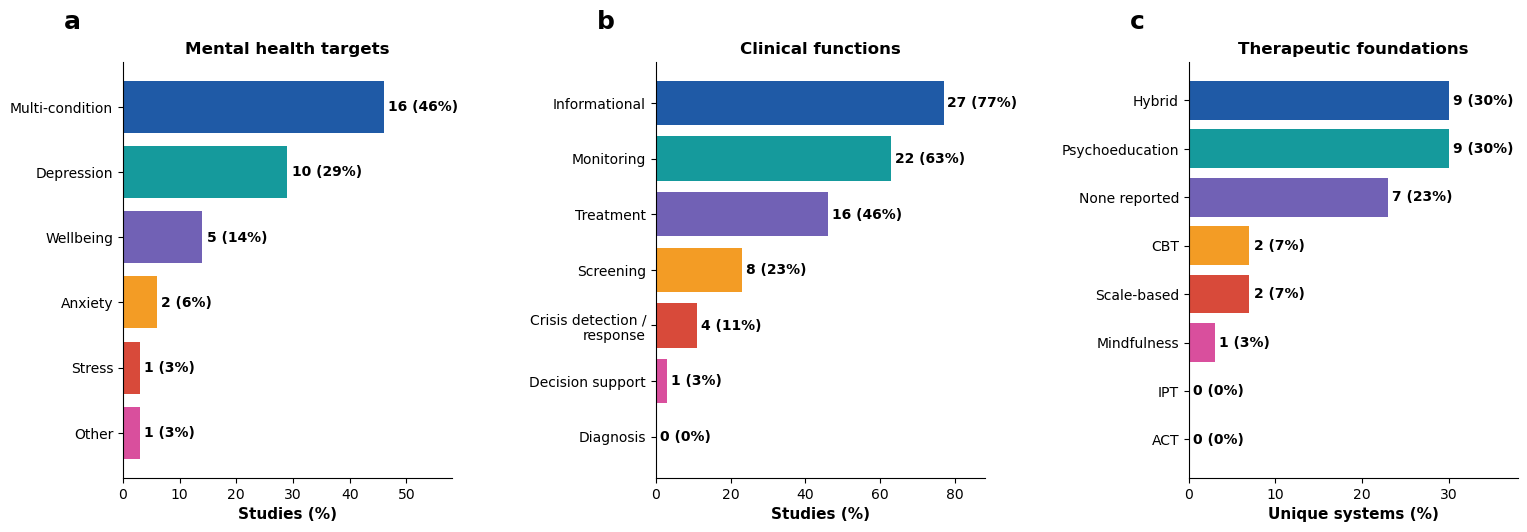

In [ ]:
import matplotlib.pyplot as plt

# =========================
# DATA
# =========================

# Panel a: Mental health targets
# Mutually exclusive categories, n = 35 studies
target_labels = [
    "Multi-condition",
    "Depression",
    "Wellbeing",
    "Anxiety",
    "Stress",
    "Other"
]

target_counts = [16, 10, 5, 2, 1, 1]
target_percent = [46, 29, 14, 6, 3, 3]


# Panel b: Clinical functions
# Non-mutually exclusive categories, n = 35 studies
clinical_labels = [
    "Informational",
    "Monitoring",
    "Treatment",
    "Screening",
    "Crisis detection /\nresponse",
    "Decision support",
    "Diagnosis"
]

clinical_counts = [27, 22, 16, 8, 4, 1, 0]
clinical_percent = [77, 63, 46, 23, 11, 3, 0]


# Panel c: Therapeutic foundations
# Unique systems, n = 30
foundation_labels = [
    "Hybrid",
    "Psychoeducation",
    "None reported",
    "CBT",
    "Scale-based",
    "Mindfulness",
    "IPT",
    "ACT"
]

foundation_counts = [9, 9, 7, 2, 2, 1, 0, 0]
foundation_percent = [30, 30, 23, 7, 7, 3, 0, 0]


# =========================
# COLOURS
# =========================

target_colors = [
    "#1f5aa6",
    "#159a9c",
    "#7161b5",
    "#f39c25",
    "#d84a3a",
    "#d94f9d"
]

clinical_colors = [
    "#1f5aa6",
    "#159a9c",
    "#7161b5",
    "#f39c25",
    "#d84a3a",
    "#d94f9d",
    "#9e9e9e"
]

foundation_colors = [
    "#1f5aa6",
    "#159a9c",
    "#7161b5",
    "#f39c25",
    "#d84a3a",
    "#d94f9d",
    "#9e9e9e",
    "#9e9e9e"
]


# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5.4),
    gridspec_kw={"wspace": 0.62}
)


# =========================
# PANEL a
# =========================

axes[0].barh(
    target_labels,
    target_percent,
    color=target_colors
)

axes[0].invert_yaxis()

axes[0].set_xlabel(
    "Studies (%)",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_title(
    "Mental health targets",
    fontsize=12,
    fontweight="bold",
    pad=6
)

axes[0].set_xlim(0, 58)

for i, (count, pct) in enumerate(
    zip(target_counts, target_percent)
):
    axes[0].text(
        pct + 0.8,
        i,
        f"{count} ({pct}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

axes[0].text(
    -0.18, 1.08, "a",
    transform=axes[0].transAxes,
    fontsize=18,
    fontweight="bold"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)


# =========================
# PANEL b
# =========================

axes[1].barh(
    clinical_labels,
    clinical_percent,
    color=clinical_colors
)

axes[1].invert_yaxis()

axes[1].set_xlabel(
    "Studies (%)",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_title(
    "Clinical functions",
    fontsize=12,
    fontweight="bold",
    pad=6
)

axes[1].set_xlim(0, 88)

for i, (count, pct) in enumerate(
    zip(clinical_counts, clinical_percent)
):
    axes[1].text(
        pct + 1,
        i,
        f"{count} ({pct}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

axes[1].text(
    -0.18, 1.08, "b",
    transform=axes[1].transAxes,
    fontsize=18,
    fontweight="bold"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


# =========================
# PANEL c
# =========================

axes[2].barh(
    foundation_labels,
    foundation_percent,
    color=foundation_colors
)

axes[2].invert_yaxis()

axes[2].set_xlabel(
    "Unique systems (%)",
    fontsize=11,
    fontweight="bold"
)

axes[2].set_title(
    "Therapeutic foundations",
    fontsize=12,
    fontweight="bold",
    pad=6
)

axes[2].set_xlim(0, 38)

for i, (count, pct) in enumerate(
    zip(foundation_counts, foundation_percent)
):
    axes[2].text(
        pct + 0.5,
        i,
        f"{count} ({pct}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

axes[2].text(
    -0.18, 1.08, "c",
    transform=axes[2].transAxes,
    fontsize=18,
    fontweight="bold"
)

axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)



plt.show()

In [3]:

journal_ids = [
    1, 2, 3, 4, 5, 8, 11, 12, 14, 16, 17, 18,
    19, 20, 22, 23, 26, 27, 28, 29, 30, 31, 34, 35
]

df["venue"] = np.where(
    df["study_id"].isin(journal_ids),
    "Journal",
    "Conference"
)


# ============================================================
# 3. BASIC CHECKS
# ============================================================

print("=" * 70)
print("DATASET CHECK")
print("=" * 70)

print(f"Total studies: {len(df)}")
print("\nPublication venue counts:")
print(df["venue"].value_counts())

print("\nModel-class counts:")
print(df["model_class_analytic"].value_counts())

DATASET CHECK
Total studies: 35

Publication venue counts:
venue
Journal       24
Conference    11
Name: count, dtype: int64

Model-class counts:
model_class_analytic
Rule-based        15
Hybrid             7
LLM                6
Unspecified AI     3
Classical ML       2
Not reported       2
Name: count, dtype: int64


In [2]:
# ============================================================
# PUBLICATION VENUE ANALYSIS AND JOURNAL-ONLY SENSITIVITY TEST
# 35-study perinatal conversational-agent dataset
# ============================================================

import pandas as pd
import numpy as np
from io import StringIO
from scipy.stats import mannwhitneyu


# ============================================================
# 1. ENTER THE 35-STUDY DATASET
# ============================================================

data = """
study_id,system_group,gms_total,model_class_analytic,model_class_raw,publication_year
1,Parentbot,11,Rule-based,Rule-based,2025
2,,14,Unspecified AI,Unspecified AI,2020
3,,2,Unspecified AI,Unspecified AI,2021
4,,4,Hybrid,Hybrid,2025
5,Woebot,11,Rule-based,Unspecified AI,2023
6,,4,LLM,LLM,2025
7,,10,LLM,LLM,2025
8,,8,Rule-based,Rule-based,2022
9,,4,Classical ML,Classical ML,2020
10,,4,Classical ML,Classical ML,2024
11,,7,LLM,LLM,2025
12,,7,LLM,LLM,2025
13,,3,Hybrid,Hybrid,2024
14,ALBA,11,Rule-based,Rule-based,2025
15,,3,Hybrid,Hybrid,2025
16,,11,Rule-based,Rule-based,2024
17,Parentbot,12,Rule-based,Rule-based,2024
18,,5,Hybrid,Hybrid,2021
19,,7,Hybrid,Hybrid,2022
20,,3,LLM,LLM,2025
21,,5,Not reported,Not reported,2023
22,ALBA,14,Rule-based,Rule-based,2025
23,,8,Rule-based,Hybrid,2021
24,,6,LLM,LLM,2024
25,,6,Not reported,Not reported,2022
26,,13,Rule-based,Rule-based,2024
27,Rover,9,Rule-based,Rule-based,2025
28,,8,Rule-based,Rule-based,2025
29,,14,Hybrid,Hybrid,2024
30,Woebot,10,Rule-based,Hybrid,2023
31,,6,Unspecified AI,Unspecified AI,2023
32,,5,Rule-based,Rule-based,2019
33,,5,Hybrid,Hybrid,2018
34,Parentbot,5,Rule-based,Rule-based,2023
35,Rover,7,Rule-based,Rule-based,2025
"""

df = pd.read_csv(StringIO(data))


# ============================================================
# 2. ADD PUBLICATION VENUE
# ============================================================
# Journal studies based on your study-characteristics table.
# All remaining studies are conference papers.

journal_ids = [
    1, 2, 3, 4, 5, 8, 11, 12, 14, 16, 17, 18,
    19, 20, 22, 23, 26, 27, 28, 29, 30, 31, 34, 35
]

df["venue"] = np.where(
    df["study_id"].isin(journal_ids),
    "Journal",
    "Conference"
)


# ============================================================
# 3. BASIC CHECKS
# ============================================================

print("=" * 70)
print("DATASET CHECK")
print("=" * 70)

print(f"Total studies: {len(df)}")
print("\nPublication venue counts:")
print(df["venue"].value_counts())

print("\nModel-class counts:")
print(df["model_class_analytic"].value_counts())


# ============================================================
# 4. HELPER FUNCTION FOR MEDIAN AND IQR
# ============================================================

def describe_group(values):
    values = pd.Series(values)

    return {
        "n": len(values),
        "median": values.median(),
        "Q1": values.quantile(0.25),
        "Q3": values.quantile(0.75)
    }


# ============================================================
# ANALYSIS A
# JOURNAL VERSUS CONFERENCE GMS
# ============================================================

print("\n")
print("=" * 70)
print("ANALYSIS A: JOURNAL VS CONFERENCE GMS")
print("=" * 70)

journal_gms = df.loc[
    df["venue"] == "Journal",
    "gms_total"
]

conference_gms = df.loc[
    df["venue"] == "Conference",
    "gms_total"
]

journal_desc = describe_group(journal_gms)
conference_desc = describe_group(conference_gms)

print("\nJournal publications:")
print(f"n = {journal_desc['n']}")
print(f"Median GMS = {journal_desc['median']:.1f}")
print(
    f"IQR = {journal_desc['Q1']:.2f} to "
    f"{journal_desc['Q3']:.2f}"
)

print("\nConference publications:")
print(f"n = {conference_desc['n']}")
print(f"Median GMS = {conference_desc['median']:.1f}")
print(
    f"IQR = {conference_desc['Q1']:.2f} to "
    f"{conference_desc['Q3']:.2f}"
)


# Mann-Whitney U
u_venue, p_venue = mannwhitneyu(
    journal_gms,
    conference_gms,
    alternative="two-sided"
)

# Rank-biserial correlation
# Here U corresponds to the Journal group.
r_venue = (
    2 * u_venue /
    (len(journal_gms) * len(conference_gms))
) - 1

print("\nMann-Whitney U test:")
print(f"U = {u_venue:.1f}")
print(f"p = {p_venue:.6f}")
print(f"Rank-biserial r = {r_venue:.3f}")


# ============================================================
# 5. DISPLAY THE STUDIES IN EACH VENUE
# ============================================================

print("\nJournal study IDs:")
print(
    df.loc[
        df["venue"] == "Journal",
        "study_id"
    ].tolist()
)

print("\nConference study IDs:")
print(
    df.loc[
        df["venue"] == "Conference",
        "study_id"
    ].tolist()
)


# ============================================================
# ANALYSIS B
# SENSITIVITY 4:
# JOURNAL-ONLY RULE-BASED VS LLM + HYBRID
# ============================================================

print("\n")
print("=" * 70)
print("ANALYSIS B: SENSITIVITY 4")
print("JOURNAL-ONLY RULE-BASED VS LLM + HYBRID")
print("=" * 70)


# Restrict dataset to journal publications
journal_df = df[
    df["venue"] == "Journal"
].copy()


# Rule-based journal studies
rule_journal_df = journal_df[
    journal_df["model_class_analytic"] == "Rule-based"
].copy()


# LLM + Hybrid journal studies
llm_hybrid_journal_df = journal_df[
    journal_df["model_class_analytic"].isin(
        ["LLM", "Hybrid"]
    )
].copy()


rule_scores = rule_journal_df["gms_total"]
llm_hybrid_scores = llm_hybrid_journal_df["gms_total"]


# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================

rule_desc = describe_group(rule_scores)
llm_hybrid_desc = describe_group(llm_hybrid_scores)

print("\nRule-based journal studies:")
print(f"n = {rule_desc['n']}")
print(f"Study IDs = {rule_journal_df['study_id'].tolist()}")
print(f"GMS scores = {sorted(rule_scores.tolist())}")
print(f"Median GMS = {rule_desc['median']:.1f}")
print(
    f"IQR = {rule_desc['Q1']:.1f} to "
    f"{rule_desc['Q3']:.1f}"
)


print("\nLLM + Hybrid journal studies:")
print(f"n = {llm_hybrid_desc['n']}")
print(
    "Study IDs = "
    f"{llm_hybrid_journal_df['study_id'].tolist()}"
)
print(
    "GMS scores = "
    f"{sorted(llm_hybrid_scores.tolist())}"
)
print(
    f"Median GMS = {llm_hybrid_desc['median']:.1f}"
)
print(
    f"IQR = {llm_hybrid_desc['Q1']:.1f} to "
    f"{llm_hybrid_desc['Q3']:.1f}"
)


# ============================================================
# 7. MANN-WHITNEY U TEST
# ============================================================

u_journal, p_journal = mannwhitneyu(
    rule_scores,
    llm_hybrid_scores,
    alternative="two-sided"
)


# ============================================================
# 8. RANK-BISERIAL EFFECT SIZE
# ============================================================

r_journal = (
    2 * u_journal /
    (len(rule_scores) * len(llm_hybrid_scores))
) - 1


print("\nJournal-only Mann-Whitney U test:")
print(f"U = {u_journal:.1f}")
print(f"p = {p_journal:.6f}")
print(f"Rank-biserial r = {r_journal:.3f}")


# ============================================================
# 9. IDENTIFY EXCLUDED JOURNAL STUDIES
# ============================================================

excluded_journal = journal_df[
    ~journal_df["model_class_analytic"].isin(
        ["Rule-based", "LLM", "Hybrid"]
    )
][
    [
        "study_id",
        "gms_total",
        "model_class_analytic"
    ]
]


print("\nJournal studies excluded from the Rule-based vs LLM+Hybrid")
print("architecture comparison:")
print(excluded_journal.to_string(index=False))


# ============================================================
# 10. PUBLICATION-READY OUTPUT
# ============================================================

print("\n")
print("=" * 70)
print("PUBLICATION-READY SUMMARY")
print("=" * 70)

print(
    "\nA. Venue comparison:\n"
    f"Journal publications (n={len(journal_gms)}) had a median "
    f"GMS of {journal_desc['median']:.1f}/24 "
    f"(IQR {journal_desc['Q1']:.2f}-{journal_desc['Q3']:.2f}), "
    f"compared with {conference_desc['median']:.1f}/24 "
    f"(IQR {conference_desc['Q1']:.1f}-{conference_desc['Q3']:.1f}) "
    f"for conference publications (n={len(conference_gms)}). "
    f"Mann-Whitney U={u_venue:.1f}, "
    f"p={p_venue:.4f}, "
    f"rank-biserial r={r_venue:.2f}."
)


print(
    "\nB. Sensitivity 4:\n"
    f"Among peer-reviewed journal publications, "
    f"rule-based studies (n={len(rule_scores)}) had a median "
    f"GMS of {rule_desc['median']:.1f}/24 "
    f"(IQR {rule_desc['Q1']:.1f}-{rule_desc['Q3']:.1f}), "
    f"compared with {llm_hybrid_desc['median']:.1f}/24 "
    f"(IQR {llm_hybrid_desc['Q1']:.1f}-"
    f"{llm_hybrid_desc['Q3']:.1f}) "
    f"for LLM and hybrid studies combined "
    f"(n={len(llm_hybrid_scores)}). "
    f"U={u_journal:.1f}, "
    f"p={p_journal:.4f}, "
    f"rank-biserial r={r_journal:.2f}."
)


# ============================================================
# 11. SHORT SUPPLEMENTARY-TABLE FORMAT
# ============================================================

print("\n")
print("=" * 70)
print("SUPPLEMENTARY TABLE S13b FORMAT")
print("=" * 70)

print(
    f"Sensitivity 4 (peer-reviewed journal publications only): "
    f"U = {u_journal:.1f}, "
    f"p = {p_journal:.3f}, "
    f"r = {r_journal:.2f} — holds."
)


# ============================================================
# 12. EXACT STUDY MEMBERSHIP FOR S13b
# ============================================================

print("\nSensitivity 4 derivation:")

print(
    f"Rule-based journals (n={len(rule_journal_df)}): "
    + ", ".join(
        str(x)
        for x in rule_journal_df["study_id"].tolist()
    )
)

print(
    f"LLM + Hybrid journals (n={len(llm_hybrid_journal_df)}): "
    + ", ".join(
        str(x)
        for x in llm_hybrid_journal_df["study_id"].tolist()
    )
)

print(
    "Excluded journal studies because model class was "
    "Unspecified AI: "
    + ", ".join(
        str(x)
        for x in excluded_journal.loc[
            excluded_journal["model_class_analytic"]
            == "Unspecified AI",
            "study_id"
        ].tolist()
    )
)

DATASET CHECK
Total studies: 35

Publication venue counts:
venue
Journal       24
Conference    11
Name: count, dtype: int64

Model-class counts:
model_class_analytic
Rule-based        15
Hybrid             7
LLM                6
Unspecified AI     3
Classical ML       2
Not reported       2
Name: count, dtype: int64


ANALYSIS A: JOURNAL VS CONFERENCE GMS

Journal publications:
n = 24
Median GMS = 8.0
IQR = 6.75 to 11.00

Conference publications:
n = 11
Median GMS = 5.0
IQR = 4.00 to 5.50

Mann-Whitney U test:
U = 216.0
p = 0.002872
Rank-biserial r = 0.636

Journal study IDs:
[1, 2, 3, 4, 5, 8, 11, 12, 14, 16, 17, 18, 19, 20, 22, 23, 26, 27, 28, 29, 30, 31, 34, 35]

Conference study IDs:
[6, 7, 9, 10, 13, 15, 21, 24, 25, 32, 33]


ANALYSIS B: SENSITIVITY 4
JOURNAL-ONLY RULE-BASED VS LLM + HYBRID

Rule-based journal studies:
n = 14
Study IDs = [1, 5, 8, 14, 16, 17, 22, 23, 26, 27, 28, 30, 34, 35]
GMS scores = [5, 7, 8, 8, 8, 9, 10, 11, 11, 11, 11, 12, 13, 14]
Median GMS = 10.5
IQR = 8.